# Notebook 33 — Per-Case Diagnostic Report Generation

This notebook creates standardized per-case diagnostic reports for selected restoration cases.

It combines existing outputs from the evaluation pipeline:

- clean reference images,
- damaged inputs,
- masks,
- OpenCV Telea restorations,
- LaMa restorations,
- Stable Diffusion restorations,
- refined reference-based metric results,
- texture and brushstroke-proxy diagnostics,
- Stable Diffusion uncertainty heatmaps when available.

The purpose is to make the evaluation framework inspectable at the individual-case level.

This notebook does not rerun restoration models and does not recompute core metrics. It assembles existing evidence into visual and HTML diagnostic reports for supervisor review and thesis writing.

In [1]:
from pathlib import Path, PureWindowsPath
import os
import json
import math
from html import escape

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)

print("Notebook 33 imports ready.")

Notebook 33 imports ready.


In [2]:
NOTEBOOK_NAME = "33_case_report_generation_cleaned"

REPO_FOLDER_NAME_CANDIDATES = [
    "painting-restoration-eval",
    "painting_restoration_eval",
]


def find_project_root(
    start_path: Path | None = None,
    repo_folder_name_candidates: list[str] | None = None,
) -> Path:
    """
    Find the project root from the current working directory.

    Supports both historical/local folder names:
    - painting-restoration-eval
    - painting_restoration_eval
    """
    if repo_folder_name_candidates is None:
        repo_folder_name_candidates = REPO_FOLDER_NAME_CANDIDATES

    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for parent in [start_path] + list(start_path.parents):
        if parent.name in repo_folder_name_candidates:
            return parent

        if (
            (parent / ".git").exists()
            and (parent / "notebooks").exists()
            and (parent / "data").exists()
            and (parent / "outputs").exists()
        ):
            return parent

        if (
            (parent / "notebooks").exists()
            and (parent / "data").exists()
            and (parent / "outputs").exists()
        ):
            return parent

    raise RuntimeError(
        f"Could not find project root from {start_path}. "
        f"Tried folder names: {repo_folder_name_candidates}"
    )


PROJECT_ROOT = find_project_root()
REPO_FOLDER_NAME = PROJECT_ROOT.name

data_dir = PROJECT_ROOT / "data"
processed_dir = data_dir / "processed"
processed_metadata_dir = processed_dir / "metadata"

outputs_dir = PROJECT_ROOT / "outputs"
metrics_dir = outputs_dir / "metrics"
reports_dir = outputs_dir / "reports"
figures_dir = outputs_dir / "figures"

case_reports_dir = reports_dir / "case_diagnostics"
case_report_pages_dir = case_reports_dir / "selected_cases"

case_figures_dir = figures_dir / "case_diagnostics"
case_grids_dir = case_figures_dir / "selected_case_grids"

for directory in [
    metrics_dir,
    reports_dir,
    figures_dir,
    case_reports_dir,
    case_report_pages_dir,
    case_figures_dir,
    case_grids_dir,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Repository folder name:", REPO_FOLDER_NAME)
print("Case reports directory:", case_reports_dir)
print("Case figures directory:", case_figures_dir)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Repository folder name: painting-restoration-eval
Case reports directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\case_diagnostics
Case figures directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\case_diagnostics


In [3]:
input_paths = {
    # Final refined controlled evaluation.
    "refined_comparison": metrics_dir / "comparison_unified_refined_opencv_lama_stable_diffusion_50.csv",

    # Texture / brushstroke-proxy layer from Notebook 31.
    "texture_unified": metrics_dir / "comparison_texture_unified_50.csv",
    "texture_case_winners_nonzero": metrics_dir / "comparison_texture_case_winners_nonzero_50.csv",
    "texture_winner_summary_nonzero": metrics_dir / "comparison_texture_winner_summary_nonzero_50.csv",
    "texture_disagreement_cases": metrics_dir / "comparison_texture_disagreement_cases_50.csv",
    "texture_high_texture_brushwork_summary": metrics_dir / "comparison_texture_high_texture_brushwork_summary_50.csv",
    "brushstroke_proxy_summary_by_model": metrics_dir / "comparison_brushstroke_proxy_summary_by_model_50.csv",

    # Stable Diffusion uncertainty heatmaps from Notebook 32.
    "uncertainty_heatmap_summary_by_case": metrics_dir / "stable_diffusion_uncertainty_heatmap_summary_by_case_50.csv",
    "uncertainty_heatmap_selected_cases": metrics_dir / "stable_diffusion_uncertainty_heatmap_selected_cases_50.csv",
    "uncertainty_heatmap_vs_refined_performance": metrics_dir / "stable_diffusion_uncertainty_heatmap_vs_refined_performance_50.csv",

    # Damaged-image metadata.
    "damaged_metadata": processed_metadata_dir / "metadata_damaged_images.csv",

    # Actual restoration metadata paths from Notebooks 05, 11, and 18.
    "opencv_restored_metadata": processed_metadata_dir / "metadata_restored_opencv_telea.csv",
    "lama_restored_metadata": processed_metadata_dir / "metadata_restored_lama.csv",
    "stable_diffusion_restored_metadata": processed_metadata_dir / "metadata_restored_stable_diffusion.csv",
}

output_paths = {
    "case_diagnostic_manifest": metrics_dir / "case_diagnostic_report_manifest_50.csv",
    "case_diagnostic_selected_cases": metrics_dir / "case_diagnostic_selected_cases_50.csv",
    "case_report_index": case_reports_dir / "case_report_index.html",
}

print("Input paths:")
for name, path in input_paths.items():
    status = "exists" if path.exists() else "missing"
    print(f"- {name}: {path} [{status}]")

print("\nOutput paths:")
for name, path in output_paths.items():
    print(f"- {name}: {path}")

Input paths:
- refined_comparison: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\comparison_unified_refined_opencv_lama_stable_diffusion_50.csv [exists]
- texture_unified: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\comparison_texture_unified_50.csv [exists]
- texture_case_winners_nonzero: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\comparison_texture_case_winners_nonzero_50.csv [exists]
- texture_winner_summary_nonzero: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\comparison_texture_winner_summary_nonzero_50.csv [exists]
- texture_disagreement_cases: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\comparison_texture_disagreement_cases_50.csv [exists]
- texture_high_texture_brushwork_summary: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\comparison_texture_high_texture_brushwork_summary_50.csv [exists]
- brushstroke_proxy_summary_by_model: D:\Masters\FH\Thesis\painting-restoration-e

In [4]:
def get_repo_folder_candidates() -> list[str]:
    candidates = [
        "painting-restoration-eval",
        "painting_restoration_eval",
        REPO_FOLDER_NAME,
    ]

    return list(dict.fromkeys(candidates))


def to_project_relative_path(path_value: str | Path | None) -> str | None:
    if path_value is None:
        return None

    try:
        if pd.isna(path_value):
            return None
    except TypeError:
        pass

    path_text = str(path_value).strip()

    if not path_text:
        return None

    normalized_text = path_text.replace("\\", "/")

    for repo_folder_name in get_repo_folder_candidates():
        marker = f"/{repo_folder_name}/"

        if marker in normalized_text:
            return normalized_text.split(marker, 1)[1]

        if normalized_text.startswith(f"{repo_folder_name}/"):
            return normalized_text.split(f"{repo_folder_name}/", 1)[1]

    path = Path(normalized_text)

    if not path.is_absolute():
        return path.as_posix()

    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        pass

    windows_path = PureWindowsPath(path_text)

    for repo_folder_name in get_repo_folder_candidates():
        if repo_folder_name in windows_path.parts:
            repo_index = windows_path.parts.index(repo_folder_name)
            relative_parts = windows_path.parts[repo_index + 1:]
            return Path(*relative_parts).as_posix()

    return normalized_text


def resolve_project_path(path_value: str | Path | None) -> Path | None:
    """
    Resolve stored project paths robustly across machines.

    Handles:
    - relative project paths,
    - absolute paths from the current machine,
    - old absolute paths from another clone location,
    - old Windows D:/... paths stored in CSV metadata,
    - both hyphen and underscore repo folder names.
    """
    if path_value is None:
        return None

    try:
        if pd.isna(path_value):
            return None
    except TypeError:
        pass

    path_text = str(path_value).strip()

    if not path_text:
        return None

    normalized_text = path_text.replace("\\", "/")

    for repo_folder_name in get_repo_folder_candidates():
        marker = f"/{repo_folder_name}/"

        if marker in normalized_text:
            relative_part = normalized_text.split(marker, 1)[1]
            return PROJECT_ROOT / relative_part

        if normalized_text.startswith(f"{repo_folder_name}/"):
            relative_part = normalized_text.split(f"{repo_folder_name}/", 1)[1]
            return PROJECT_ROOT / relative_part

    windows_path = PureWindowsPath(path_text)

    for repo_folder_name in get_repo_folder_candidates():
        if repo_folder_name in windows_path.parts:
            repo_index = windows_path.parts.index(repo_folder_name)
            relative_parts = windows_path.parts[repo_index + 1:]
            return PROJECT_ROOT.joinpath(*relative_parts)

    path = Path(path_text)

    if path.is_absolute():
        if path.exists():
            return path

        for repo_folder_name in get_repo_folder_candidates():
            if repo_folder_name in path.parts:
                repo_index = path.parts.index(repo_folder_name)
                relative_parts = path.parts[repo_index + 1:]
                return PROJECT_ROOT.joinpath(*relative_parts)

        return path

    return PROJECT_ROOT / path


def find_first_existing_column(
    df: pd.DataFrame,
    candidates: list[str],
) -> str | None:
    for column in candidates:
        if column in df.columns:
            return column

    return None


def find_columns_containing(
    df: pd.DataFrame,
    tokens: list[str],
) -> list[str]:
    columns = []

    for column in df.columns:
        column_lower = column.lower()

        if all(token.lower() in column_lower for token in tokens):
            columns.append(column)

    return columns


def path_exists_from_value(path_value: str | Path | None) -> bool:
    resolved_path = resolve_project_path(path_value)

    return bool(resolved_path is not None and resolved_path.exists())


print("Path helper functions ready.")

Path helper functions ready.


In [5]:
required_input_keys = [
    "refined_comparison",
    "damaged_metadata",
    "opencv_restored_metadata",
    "lama_restored_metadata",
    "stable_diffusion_restored_metadata",
]

missing_required_inputs = [
    key
    for key in required_input_keys
    if not input_paths[key].exists()
]

if missing_required_inputs:
    for key in missing_required_inputs:
        print(f"Missing required input: {key} -> {input_paths[key]}")

    raise FileNotFoundError("One or more required Notebook 33 inputs are missing.")

optional_input_keys = [
    key
    for key in input_paths
    if key not in required_input_keys
]

missing_optional_inputs = [
    key
    for key in optional_input_keys
    if not input_paths[key].exists()
]

if missing_optional_inputs:
    print("Missing optional inputs:")
    for key in missing_optional_inputs:
        print(f"- {key}: {input_paths[key]}")

refined_comparison_df = pd.read_csv(input_paths["refined_comparison"])
damaged_metadata_df = pd.read_csv(input_paths["damaged_metadata"])

opencv_restored_metadata_df = pd.read_csv(input_paths["opencv_restored_metadata"])
lama_restored_metadata_df = pd.read_csv(input_paths["lama_restored_metadata"])
stable_diffusion_restored_metadata_df = pd.read_csv(input_paths["stable_diffusion_restored_metadata"])

optional_dataframes = {}

for key in optional_input_keys:
    path = input_paths[key]

    if path.exists():
        optional_dataframes[key] = pd.read_csv(path)
        print(f"Loaded optional dataframe: {key} {optional_dataframes[key].shape}")
    else:
        optional_dataframes[key] = pd.DataFrame()

print("\nLoaded required dataframes:")
print("refined_comparison_df:", refined_comparison_df.shape)
print("damaged_metadata_df:", damaged_metadata_df.shape)
print("opencv_restored_metadata_df:", opencv_restored_metadata_df.shape)
print("lama_restored_metadata_df:", lama_restored_metadata_df.shape)
print("stable_diffusion_restored_metadata_df:", stable_diffusion_restored_metadata_df.shape)

print("\nLoaded optional dataframes:")
for key, df in optional_dataframes.items():
    status = "loaded" if not df.empty else "empty/missing"
    print(f"- {key}: {df.shape} [{status}]")

print("\nRefined comparison columns:")
display(pd.DataFrame({"column": refined_comparison_df.columns}))

print("\nDamaged metadata columns:")
display(pd.DataFrame({"column": damaged_metadata_df.columns}))

print("\nOpenCV restored metadata columns:")
display(pd.DataFrame({"column": opencv_restored_metadata_df.columns}))

print("\nLaMa restored metadata columns:")
display(pd.DataFrame({"column": lama_restored_metadata_df.columns}))

print("\nStable Diffusion restored metadata columns:")
display(pd.DataFrame({"column": stable_diffusion_restored_metadata_df.columns}))

Loaded optional dataframe: texture_unified (750, 102)
Loaded optional dataframe: texture_case_winners_nonzero (200, 16)
Loaded optional dataframe: texture_winner_summary_nonzero (3, 2)
Loaded optional dataframe: texture_disagreement_cases (200, 21)
Loaded optional dataframe: texture_high_texture_brushwork_summary (15, 11)
Loaded optional dataframe: brushstroke_proxy_summary_by_model (3, 6)
Loaded optional dataframe: uncertainty_heatmap_summary_by_case (40, 60)
Loaded optional dataframe: uncertainty_heatmap_selected_cases (22, 124)
Loaded optional dataframe: uncertainty_heatmap_vs_refined_performance (40, 119)

Loaded required dataframes:
refined_comparison_df: (200, 40)
damaged_metadata_df: (250, 19)
opencv_restored_metadata_df: (250, 20)
lama_restored_metadata_df: (250, 32)
stable_diffusion_restored_metadata_df: (250, 36)

Loaded optional dataframes:
- texture_unified: (750, 102) [loaded]
- texture_case_winners_nonzero: (200, 16) [loaded]
- texture_winner_summary_nonzero: (3, 2) [load

,column
0,case_id
1,painting_id
2,mask_id
3,mask_type
4,category
5,title
6,opencv_telea_mse_improvement
7,opencv_telea_psnr_improvement
8,opencv_telea_ssim_improvement
9,opencv_telea_lpips_improvement



Damaged metadata columns:


,column
0,case_id
1,painting_id
2,mask_id
3,mask_type
4,clean_filename
5,clean_path
6,mask_filename
7,mask_path
8,damaged_filename
9,damaged_path



OpenCV restored metadata columns:


,column
0,case_id
1,painting_id
2,mask_id
3,mask_type
4,model_name
5,algorithm
6,inpaint_radius
7,clean_filename
8,clean_path
9,mask_filename



LaMa restored metadata columns:


,column
0,case_id
1,painting_id
2,mask_id
3,mask_type
4,clean_filename
5,clean_path
6,mask_filename
7,mask_path
8,damaged_filename
9,damaged_path



Stable Diffusion restored metadata columns:


,column
0,case_id
1,painting_id
2,mask_id
3,mask_type
4,clean_filename
5,clean_path
6,mask_filename
7,mask_path
8,damaged_filename
9,damaged_path


In [6]:
def standardize_refined_comparison(
    refined_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Standardize final refined comparison rows to one row per restoration case.
    """
    required_columns = [
        "case_id",
        "painting_id",
        "mask_type",
        "category",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in refined_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Refined comparison missing required columns: {missing_columns}"
        )

    standardized_df = refined_df.copy()

    standardized_df["case_id"] = standardized_df["case_id"].astype(str)
    standardized_df["painting_id"] = standardized_df["painting_id"].astype(str)
    standardized_df["mask_type"] = standardized_df["mask_type"].astype(str)
    standardized_df["category"] = standardized_df["category"].astype(str)

    if standardized_df["case_id"].duplicated().any():
        duplicate_cases = standardized_df[
            standardized_df["case_id"].duplicated(keep=False)
        ].sort_values("case_id")

        display(duplicate_cases.head(20))

        raise ValueError("Refined comparison contains duplicate case_id rows.")

    return standardized_df


case_base_df = standardize_refined_comparison(refined_comparison_df)

print("Base case dataframe:", case_base_df.shape)
print("Unique cases:", case_base_df["case_id"].nunique())

display(case_base_df.head())

Base case dataframe: (200, 40)
Unique cases: 200


,case_id,painting_id,mask_id,mask_type,category,title,opencv_telea_mse_improvement,opencv_telea_psnr_improvement,opencv_telea_ssim_improvement,opencv_telea_lpips_improvement,opencv_telea_clip_improvement,opencv_telea_dinov2_improvement,lama_mse_improvement,lama_psnr_improvement,lama_ssim_improvement,lama_lpips_improvement,lama_clip_improvement,lama_dinov2_improvement,stable_diffusion_inpainting_mse_improvement,stable_diffusion_inpainting_psnr_improvement,stable_diffusion_inpainting_ssim_improvement,stable_diffusion_inpainting_lpips_improvement,stable_diffusion_inpainting_clip_improvement,stable_diffusion_inpainting_dinov2_improvement,winner_mse_improvement,winner_psnr_improvement,winner_ssim_improvement,winner_lpips_improvement,winner_clip_improvement,winner_dinov2_improvement,opencv_telea_metric_wins,lama_metric_wins,stable_diffusion_inpainting_metric_wins,metric_ties,overall_metric_vote,mixed_metric_outcome,all_metrics_same_winner,opencv_telea_all_metrics_win,lama_all_metrics_win,stable_diffusion_inpainting_all_metrics_win
0,p001_loss_large,p001,p001_loss_large,loss_large,portrait_figure,Juan de Pareja,48015.951050,16.981299,0.307164,0.318226,-0.002892,0.041827,48703.631836,22.215740,0.319821,0.444638,0.166787,0.253627,48133.030640,17.532740,0.118627,0.391132,0.119137,0.248403,lama,lama,lama,lama,lama,lama,0,6,0,0,lama,False,True,False,True,False
1,p001_loss_small,p001,p001_loss_small,loss_small,portrait_figure,Juan de Pareja,46962.810768,31.576516,0.079075,0.333183,0.088604,0.048946,46980.140714,34.856852,0.078012,0.338072,0.089109,0.050690,46912.756538,27.543226,-0.077822,0.306002,0.071142,0.037632,lama,lama,opencv_telea,lama,lama,lama,1,5,0,0,lama,True,False,False,False,False
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,portrait_figure,Juan de Pareja,50520.931183,23.633919,0.085103,0.385844,0.098557,0.179656,50444.495941,22.337666,0.083534,0.391770,0.102389,0.197233,49826.728882,17.444243,-0.093749,0.244464,0.060504,0.167937,opencv_telea,opencv_telea,opencv_telea,lama,lama,lama,3,3,0,0,tie_lama_opencv_telea,True,False,False,False,False
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,portrait_figure,Juan de Pareja,48335.436569,24.474660,0.047276,0.419886,0.141666,0.074026,48363.675125,25.248112,0.047212,0.420297,0.141728,0.074596,42301.111328,8.929056,-0.153775,0.161720,0.043441,-0.005591,lama,lama,opencv_telea,lama,lama,lama,1,5,0,0,lama,True,False,False,False,False
4,p002_loss_large,p002,p002_loss_large,loss_large,portrait_figure,Madame X (Madame Pierre Gautreau),50914.557739,22.108130,0.375796,0.387116,0.099515,0.011488,51135.079025,27.328406,0.405204,0.448236,0.245552,0.172309,50524.246399,18.609613,0.212932,0.407476,0.222473,0.119677,lama,lama,lama,lama,lama,lama,0,6,0,0,lama,False,True,False,True,False


In [8]:
def enrich_case_paths_from_damaged_metadata(
    case_df: pd.DataFrame,
    damaged_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add clean/damaged/mask paths from damaged metadata.

    Category, mask_type, and painting_id are already expected from case_base_df.
    Damaged metadata is used mainly for image/mask paths.
    """
    if "case_id" not in damaged_df.columns:
        raise ValueError("Damaged metadata must contain case_id.")

    damaged_lookup_columns = [
        column
        for column in [
            "case_id",
            "painting_id",
            "mask_id",
            "mask_type",
            "category",
            "title",
            "clean_path",
            "clean_image_path",
            "processed_image_path",
            "damaged_path",
            "damaged_image_path",
            "mask_path",
            "mask_image_path",
        ]
        if column in damaged_df.columns
    ]

    damaged_lookup_df = (
        damaged_df[damaged_lookup_columns]
        .drop_duplicates(subset=["case_id"])
        .copy()
    )

    damaged_lookup_df["case_id"] = damaged_lookup_df["case_id"].astype(str)

    enriched_df = case_df.copy()
    enriched_df["case_id"] = enriched_df["case_id"].astype(str)

    enriched_df = enriched_df.merge(
        damaged_lookup_df,
        on="case_id",
        how="left",
        suffixes=("", "_damaged"),
    )

    # Preserve existing case_base_df values first. Fill only if damaged metadata has extras.
    for base_column in [
        "painting_id",
        "mask_id",
        "mask_type",
        "category",
        "title",
    ]:
        damaged_column = f"{base_column}_damaged"

        if damaged_column in enriched_df.columns:
            if base_column not in enriched_df.columns:
                enriched_df[base_column] = enriched_df[damaged_column]
            else:
                enriched_df[base_column] = enriched_df[base_column].fillna(
                    enriched_df[damaged_column]
                )

            enriched_df = enriched_df.drop(columns=[damaged_column])

    # Canonical clean/damaged/mask path columns.
    if "clean_image_path" not in enriched_df.columns:
        if "clean_path" in enriched_df.columns:
            enriched_df["clean_image_path"] = enriched_df["clean_path"]
        elif "processed_image_path" in enriched_df.columns:
            enriched_df["clean_image_path"] = enriched_df["processed_image_path"]

    if "damaged_image_path" not in enriched_df.columns:
        if "damaged_path" in enriched_df.columns:
            enriched_df["damaged_image_path"] = enriched_df["damaged_path"]

    if "mask_image_path" not in enriched_df.columns:
        if "mask_path" in enriched_df.columns:
            enriched_df["mask_image_path"] = enriched_df["mask_path"]

    return enriched_df


def standardize_restoration_metadata(
    metadata_df: pd.DataFrame,
    *,
    model_name: str,
    output_column: str,
) -> pd.DataFrame:
    """
    Standardize restoration metadata from Notebooks 05, 11, and 18.

    Expected source schema:
    - case_id
    - restored_path
    - status, optional
    """
    required_columns = [
        "case_id",
        "restored_path",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in metadata_df.columns
    ]

    if missing_columns:
        print(f"{model_name} metadata columns:")
        display(pd.DataFrame({"column": metadata_df.columns}))

        raise ValueError(
            f"{model_name} metadata missing required columns: {missing_columns}"
        )

    standardized_df = metadata_df.copy()
    standardized_df["case_id"] = standardized_df["case_id"].astype(str)

    if "status" in standardized_df.columns:
        non_ok_df = standardized_df[
            standardized_df["status"].astype(str).str.lower() != "ok"
        ]

        if not non_ok_df.empty:
            print(f"{model_name} non-ok restoration rows:")
            display(non_ok_df[["case_id", "status"]].head(30))

            raise ValueError(f"{model_name} restoration metadata contains non-ok rows.")

    standardized_df = standardized_df[
        [
            column
            for column in [
                "case_id",
                "restored_path",
                "status",
                "issue",
                "inference_mode",
                "model_name",
            ]
            if column in standardized_df.columns
        ]
    ].copy()

    standardized_df = standardized_df.rename(
        columns={
            "restored_path": output_column,
        }
    )

    standardized_df = standardized_df.dropna(subset=["case_id", output_column])

    if standardized_df["case_id"].duplicated().any():
        duplicate_rows = standardized_df[
            standardized_df["case_id"].duplicated(keep=False)
        ].sort_values("case_id")

        print(f"{model_name} duplicate case_id rows:")
        display(duplicate_rows.head(30))

        raise ValueError(f"{model_name} restoration metadata contains duplicate case_id rows.")

    print(
        f"{model_name}: standardized {len(standardized_df)} rows using restored_path -> {output_column}"
    )

    return standardized_df


case_paths_df = enrich_case_paths_from_damaged_metadata(
    case_base_df,
    damaged_metadata_df,
)

opencv_paths_df = standardize_restoration_metadata(
    opencv_restored_metadata_df,
    model_name="OpenCV Telea",
    output_column="opencv_image_path",
)

lama_paths_df = standardize_restoration_metadata(
    lama_restored_metadata_df,
    model_name="LaMa",
    output_column="lama_image_path",
)

stable_diffusion_paths_df = standardize_restoration_metadata(
    stable_diffusion_restored_metadata_df,
    model_name="Stable Diffusion",
    output_column="stable_diffusion_image_path",
)

case_paths_df = case_paths_df.merge(
    opencv_paths_df[["case_id", "opencv_image_path"]],
    on="case_id",
    how="left",
)

case_paths_df = case_paths_df.merge(
    lama_paths_df[["case_id", "lama_image_path"]],
    on="case_id",
    how="left",
)

case_paths_df = case_paths_df.merge(
    stable_diffusion_paths_df[["case_id", "stable_diffusion_image_path"]],
    on="case_id",
    how="left",
)

required_visual_columns = [
    "case_id",
    "painting_id",
    "mask_type",
    "category",
    "clean_image_path",
    "damaged_image_path",
    "mask_image_path",
    "opencv_image_path",
    "lama_image_path",
    "stable_diffusion_image_path",
]

missing_visual_columns = [
    column
    for column in required_visual_columns
    if column not in case_paths_df.columns
]

if missing_visual_columns:
    print("Available case path columns:")
    display(pd.DataFrame({"column": case_paths_df.columns}))

    raise ValueError(
        f"Missing required visual columns after path standardization: {missing_visual_columns}"
    )

null_visual_counts = case_paths_df[required_visual_columns].isna().sum()

if (null_visual_counts > 0).any():
    print("Null counts in required visual columns:")
    display(null_visual_counts)

    print("\nRows with null visual values:")
    display(
        case_paths_df[
            case_paths_df[required_visual_columns].isna().any(axis=1)
        ][required_visual_columns].head(50)
    )

    print("\nMerge coverage:")
    print("Base cases:", case_paths_df["case_id"].nunique())
    print("OpenCV matched cases:", case_paths_df["opencv_image_path"].notna().sum())
    print("LaMa matched cases:", case_paths_df["lama_image_path"].notna().sum())
    print("Stable Diffusion matched cases:", case_paths_df["stable_diffusion_image_path"].notna().sum())

    print("\nCase base columns:")
    display(pd.DataFrame({"column": case_base_df.columns}))

    print("\nDamaged metadata columns:")
    display(pd.DataFrame({"column": damaged_metadata_df.columns}))

    raise ValueError("Some required visual path columns contain null values.")

visual_path_columns = [
    "clean_image_path",
    "damaged_image_path",
    "mask_image_path",
    "opencv_image_path",
    "lama_image_path",
    "stable_diffusion_image_path",
]

missing_visual_files = []

for _, row in case_paths_df.iterrows():
    for column in visual_path_columns:
        resolved_path = resolve_project_path(row[column])

        if resolved_path is None or not resolved_path.exists():
            missing_visual_files.append(
                {
                    "case_id": row["case_id"],
                    "column": column,
                    "raw_path": row[column],
                    "resolved_path": resolved_path,
                }
            )

if missing_visual_files:
    print("Missing visual files:")
    display(pd.DataFrame(missing_visual_files).head(60))

    raise FileNotFoundError(
        f"{len(missing_visual_files)} required visual files could not be resolved."
    )

for column in visual_path_columns:
    case_paths_df[f"{column}_relative"] = case_paths_df[column].apply(to_project_relative_path)

print("Case visual path dataframe ready.")
print("Rows:", len(case_paths_df))
print("Unique cases:", case_paths_df["case_id"].nunique())

print("\nResolved visual path columns:")
display(
    pd.DataFrame(
        {
            "visual_column": visual_path_columns,
            "non_null_count": [case_paths_df[column].notna().sum() for column in visual_path_columns],
            "existing_file_count": [
                case_paths_df[column].apply(path_exists_from_value).sum()
                for column in visual_path_columns
            ],
        }
    )
)

print("\nCase counts by mask type:")
display(
    case_paths_df["mask_type"]
    .value_counts()
    .sort_index()
    .rename_axis("mask_type")
    .reset_index(name="case_count")
)

print("\nCase counts by category:")
display(
    case_paths_df["category"]
    .value_counts()
    .sort_index()
    .rename_axis("category")
    .reset_index(name="case_count")
)

print("\nSample visual paths:")
display(
    case_paths_df[
        [
            "case_id",
            "category",
            "mask_type",
            "clean_image_path_relative",
            "damaged_image_path_relative",
            "mask_image_path_relative",
            "opencv_image_path_relative",
            "lama_image_path_relative",
            "stable_diffusion_image_path_relative",
        ]
    ].head()
)

OpenCV Telea: standardized 250 rows using restored_path -> opencv_image_path
LaMa: standardized 250 rows using restored_path -> lama_image_path
Stable Diffusion: standardized 250 rows using restored_path -> stable_diffusion_image_path
Case visual path dataframe ready.
Rows: 200
Unique cases: 200

Resolved visual path columns:


,visual_column,non_null_count,existing_file_count
0,clean_image_path,200,200
1,damaged_image_path,200,200
2,mask_image_path,200,200
3,opencv_image_path,200,200
4,lama_image_path,200,200
5,stable_diffusion_image_path,200,200



Case counts by mask type:


,mask_type,case_count
0,loss_large,50
1,loss_small,50
2,mixed_damage,50
3,scratch_thin,50



Case counts by category:


,category,case_count
0,abstraction_surrealism,40
1,architecture_structured,40
2,high_texture_brushwork,40
3,landscape_natural,40
4,portrait_figure,40



Sample visual paths:


,case_id,category,mask_type,clean_image_path_relative,damaged_image_path_relative,mask_image_path_relative,opencv_image_path_relative,lama_image_path_relative,stable_diffusion_image_path_relative
0,p001_loss_large,portrait_figure,loss_large,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_large_damaged.png,data/processed/masks/p001_loss_large_mask.png,data/processed/restored/opencv_telea/p001_loss...,data/processed/restored/lama/p001_loss_large_r...,data/processed/restored/stable_diffusion_inpai...
1,p001_loss_small,portrait_figure,loss_small,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_small_damaged.png,data/processed/masks/p001_loss_small_mask.png,data/processed/restored/opencv_telea/p001_loss...,data/processed/restored/lama/p001_loss_small_r...,data/processed/restored/stable_diffusion_inpai...
2,p001_mixed_damage,portrait_figure,mixed_damage,data/processed/clean/p001_clean.png,data/processed/masked/p001_mixed_damage_damage...,data/processed/masks/p001_mixed_damage_mask.png,data/processed/restored/opencv_telea/p001_mixe...,data/processed/restored/lama/p001_mixed_damage...,data/processed/restored/stable_diffusion_inpai...
3,p001_scratch_thin,portrait_figure,scratch_thin,data/processed/clean/p001_clean.png,data/processed/masked/p001_scratch_thin_damage...,data/processed/masks/p001_scratch_thin_mask.png,data/processed/restored/opencv_telea/p001_scra...,data/processed/restored/lama/p001_scratch_thin...,data/processed/restored/stable_diffusion_inpai...
4,p002_loss_large,portrait_figure,loss_large,data/processed/clean/p002_clean.png,data/processed/masked/p002_loss_large_damaged.png,data/processed/masks/p002_loss_large_mask.png,data/processed/restored/opencv_telea/p002_loss...,data/processed/restored/lama/p002_loss_large_r...,data/processed/restored/stable_diffusion_inpai...


In [9]:
def prepare_texture_case_winners(
    texture_winners_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prepare Notebook 31 texture winner data at case level.

    Expected Notebook 31 output:
    comparison_texture_case_winners_nonzero_50.csv
    """
    if texture_winners_df.empty:
        return pd.DataFrame({"case_id": []})

    prepared_df = texture_winners_df.copy()

    if "case_id" not in prepared_df.columns:
        print("Texture winners file has no case_id column. Skipping texture winner merge.")
        return pd.DataFrame({"case_id": []})

    prepared_df["case_id"] = prepared_df["case_id"].astype(str)

    useful_columns = [
        column
        for column in [
            "case_id",
            "category",
            "mask_type",
            "texture_winner",
            "texture_winner_model",
            "combined_texture_distance_winner",
            "combined_texture_distance_mean_winner",
            "combined_texture_distance_norm_winner",
            "glcm_texture_distance_mean_winner",
            "gabor_texture_distance_mean_winner",
            "brushstroke_proxy_distance_mean_winner",
            "texture_winner_is_refined_winner",
            "texture_refined_agreement",
        ]
        if column in prepared_df.columns
    ]

    if useful_columns == ["case_id"]:
        # Fall back to preserving compact non-path, non-large columns.
        useful_columns = [
            column
            for column in prepared_df.columns
            if column == "case_id"
            or (
                "path" not in column.lower()
                and "image" not in column.lower()
                and "array" not in column.lower()
            )
        ]

    prepared_df = prepared_df[useful_columns].drop_duplicates(subset=["case_id"], keep="last")

    # Prefix non-key columns to avoid collisions.
    rename_map = {
        column: f"texture_{column}"
        for column in prepared_df.columns
        if column != "case_id" and not column.startswith("texture_")
    }

    prepared_df = prepared_df.rename(columns=rename_map)

    return prepared_df


def prepare_texture_disagreements(
    texture_disagreement_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prepare Notebook 31 texture disagreement data.
    """
    if texture_disagreement_df.empty:
        return pd.DataFrame({"case_id": []})

    prepared_df = texture_disagreement_df.copy()

    if "case_id" not in prepared_df.columns:
        print("Texture disagreement file has no case_id column. Skipping disagreement merge.")
        return pd.DataFrame({"case_id": []})

    prepared_df["case_id"] = prepared_df["case_id"].astype(str)
    prepared_df["has_texture_disagreement"] = True

    useful_columns = [
        column
        for column in prepared_df.columns
        if column == "case_id"
        or column == "has_texture_disagreement"
        or (
            "winner" in column.lower()
            or "disagreement" in column.lower()
            or "distance" in column.lower()
        )
    ]

    prepared_df = prepared_df[useful_columns].drop_duplicates(subset=["case_id"], keep="last")

    rename_map = {
        column: f"texture_disagreement_{column}"
        for column in prepared_df.columns
        if column not in ["case_id", "has_texture_disagreement"]
        and not column.startswith("texture_disagreement_")
    }

    prepared_df = prepared_df.rename(columns=rename_map)

    return prepared_df


def prepare_uncertainty_heatmap_case_data(
    uncertainty_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prepare Notebook 32 uncertainty heatmap summaries at case level.
    """
    if uncertainty_df.empty:
        return pd.DataFrame({"case_id": []})

    prepared_df = uncertainty_df.copy()

    if "case_id" not in prepared_df.columns:
        print("Uncertainty heatmap file has no case_id column. Skipping uncertainty merge.")
        return pd.DataFrame({"case_id": []})

    prepared_df["case_id"] = prepared_df["case_id"].astype(str)

    useful_columns = [
        column
        for column in [
            "case_id",
            "masked_mean_uncertainty",
            "masked_p95_uncertainty",
            "bbox_mean_uncertainty",
            "bbox_p95_uncertainty",
            "boundary_mean_uncertainty",
            "boundary_p95_uncertainty",
            "outside_mask_mean_uncertainty",
            "outside_mask_p95_uncertainty",
            "masked_vs_global_mean_uncertainty_ratio",
            "boundary_vs_global_mean_uncertainty_ratio",
            "heatmap_png_path",
            "overlay_png_path",
            "compact_figure_path",
            "heatmap_status",
        ]
        if column in prepared_df.columns
    ]

    prepared_df = prepared_df[useful_columns].drop_duplicates(subset=["case_id"], keep="last")

    rename_map = {
        column: f"uncertainty_{column}"
        for column in prepared_df.columns
        if column != "case_id" and not column.startswith("uncertainty_")
    }

    prepared_df = prepared_df.rename(columns=rename_map)
    prepared_df["has_uncertainty_heatmap"] = prepared_df.get("uncertainty_heatmap_status", "ok").eq("ok")

    return prepared_df


def prepare_uncertainty_selected_cases(
    selected_uncertainty_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prepare Notebook 32 selected uncertainty case reasons.
    """
    if selected_uncertainty_df.empty:
        return pd.DataFrame({"case_id": []})

    prepared_df = selected_uncertainty_df.copy()

    if "case_id" not in prepared_df.columns:
        return pd.DataFrame({"case_id": []})

    prepared_df["case_id"] = prepared_df["case_id"].astype(str)

    useful_columns = [
        column
        for column in [
            "case_id",
            "selection_reasons",
            "selection_count",
            "selected_detail_figure_path",
        ]
        if column in prepared_df.columns
    ]

    prepared_df = prepared_df[useful_columns].drop_duplicates(subset=["case_id"], keep="last")

    rename_map = {
        column: f"uncertainty_selected_{column}"
        for column in prepared_df.columns
        if column != "case_id" and not column.startswith("uncertainty_selected_")
    }

    return prepared_df.rename(columns=rename_map)


case_diagnostic_df = case_paths_df.copy()
case_diagnostic_df["case_id"] = case_diagnostic_df["case_id"].astype(str)

texture_winners_prepared_df = prepare_texture_case_winners(
    optional_dataframes.get("texture_case_winners_nonzero", pd.DataFrame())
)

texture_disagreements_prepared_df = prepare_texture_disagreements(
    optional_dataframes.get("texture_disagreement_cases", pd.DataFrame())
)

uncertainty_heatmap_prepared_df = prepare_uncertainty_heatmap_case_data(
    optional_dataframes.get("uncertainty_heatmap_summary_by_case", pd.DataFrame())
)

uncertainty_selected_prepared_df = prepare_uncertainty_selected_cases(
    optional_dataframes.get("uncertainty_heatmap_selected_cases", pd.DataFrame())
)

for label, merge_df in [
    ("texture_winners", texture_winners_prepared_df),
    ("texture_disagreements", texture_disagreements_prepared_df),
    ("uncertainty_heatmaps", uncertainty_heatmap_prepared_df),
    ("uncertainty_selected", uncertainty_selected_prepared_df),
]:
    if not merge_df.empty and "case_id" in merge_df.columns and len(merge_df.columns) > 1:
        case_diagnostic_df = case_diagnostic_df.merge(
            merge_df,
            on="case_id",
            how="left",
        )
        print(f"Merged {label}: {merge_df.shape}")
    else:
        print(f"Skipped {label}: no usable case-level columns.")

if "has_texture_disagreement" not in case_diagnostic_df.columns:
    case_diagnostic_df["has_texture_disagreement"] = False
else:
    case_diagnostic_df["has_texture_disagreement"] = case_diagnostic_df["has_texture_disagreement"].fillna(False)

if "has_uncertainty_heatmap" not in case_diagnostic_df.columns:
    case_diagnostic_df["has_uncertainty_heatmap"] = False
else:
    case_diagnostic_df["has_uncertainty_heatmap"] = case_diagnostic_df["has_uncertainty_heatmap"].fillna(False)

print("Case diagnostic master table:", case_diagnostic_df.shape)
print("Cases:", case_diagnostic_df["case_id"].nunique())

print("\nCoverage:")
coverage_rows = []

for column in [
    "has_texture_disagreement",
    "has_uncertainty_heatmap",
    "uncertainty_masked_mean_uncertainty",
    "uncertainty_boundary_mean_uncertainty",
]:
    if column in case_diagnostic_df.columns:
        coverage_rows.append(
            {
                "field": column,
                "non_null_or_true_count": int(
                    case_diagnostic_df[column].sum()
                    if case_diagnostic_df[column].dtype == bool
                    else case_diagnostic_df[column].notna().sum()
                ),
            }
        )

display(pd.DataFrame(coverage_rows))

display(case_diagnostic_df.head())

Merged texture_winners: (200, 4)
Merged texture_disagreements: (200, 13)
Merged uncertainty_heatmaps: (40, 16)
Merged uncertainty_selected: (22, 4)
Case diagnostic master table: (200, 88)
Cases: 200

Coverage:


E:\HFCache\tmp\ipykernel_54480\1063465373.py:246: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  case_diagnostic_df["has_uncertainty_heatmap"] = case_diagnostic_df["has_uncertainty_heatmap"].fillna(False)


,field,non_null_or_true_count
0,has_texture_disagreement,200
1,has_uncertainty_heatmap,40
2,uncertainty_masked_mean_uncertainty,40
3,uncertainty_boundary_mean_uncertainty,40


,case_id,painting_id,mask_id,mask_type,category,title,opencv_telea_mse_improvement,opencv_telea_psnr_improvement,opencv_telea_ssim_improvement,opencv_telea_lpips_improvement,opencv_telea_clip_improvement,opencv_telea_dinov2_improvement,lama_mse_improvement,lama_psnr_improvement,lama_ssim_improvement,lama_lpips_improvement,lama_clip_improvement,lama_dinov2_improvement,stable_diffusion_inpainting_mse_improvement,stable_diffusion_inpainting_psnr_improvement,stable_diffusion_inpainting_ssim_improvement,stable_diffusion_inpainting_lpips_improvement,stable_diffusion_inpainting_clip_improvement,stable_diffusion_inpainting_dinov2_improvement,winner_mse_improvement,winner_psnr_improvement,winner_ssim_improvement,winner_lpips_improvement,winner_clip_improvement,winner_dinov2_improvement,opencv_telea_metric_wins,lama_metric_wins,stable_diffusion_inpainting_metric_wins,metric_ties,overall_metric_vote,mixed_metric_outcome,all_metrics_same_winner,opencv_telea_all_metrics_win,lama_all_metrics_win,stable_diffusion_inpainting_all_metrics_win,clean_path,damaged_path,mask_path,clean_image_path,damaged_image_path,mask_image_path,opencv_image_path,lama_image_path,stable_diffusion_image_path,clean_image_path_relative,damaged_image_path_relative,mask_image_path_relative,opencv_image_path_relative,lama_image_path_relative,stable_diffusion_image_path_relative,texture_category,texture_mask_type,texture_winner_model,texture_disagreement_texture_winner_model,texture_disagreement_texture_winner_distance,texture_disagreement_texture_winner_glcm_distance,texture_disagreement_texture_winner_gabor_distance,texture_disagreement_texture_winner_brushstroke_proxy_distance,texture_disagreement_lama_texture_distance,texture_disagreement_lama_brushstroke_proxy_distance,texture_disagreement_opencv_telea_texture_distance,texture_disagreement_opencv_telea_brushstroke_proxy_distance,texture_disagreement_stable_diffusion_inpainting_texture_distance,texture_disagreement_stable_diffusion_inpainting_brushstroke_proxy_distance,has_texture_disagreement,uncertainty_masked_mean_uncertainty,uncertainty_masked_p95_uncertainty,uncertainty_bbox_mean_uncertainty,uncertainty_bbox_p95_uncertainty,uncertainty_boundary_mean_uncertainty,uncertainty_boundary_p95_uncertainty,uncertainty_outside_mask_mean_uncertainty,uncertainty_outside_mask_p95_uncertainty,uncertainty_masked_vs_global_mean_uncertainty_ratio,uncertainty_boundary_vs_global_mean_uncertainty_ratio,uncertainty_heatmap_png_path,uncertainty_overlay_png_path,uncertainty_compact_figure_path,uncertainty_heatmap_status,has_uncertainty_heatmap,uncertainty_selected_selection_reasons,uncertainty_selected_selection_count,uncertainty_selected_selected_detail_figure_path
0,p001_loss_large,p001,p001_loss_large,loss_large,portrait_figure,Juan de Pareja,48015.951050,16.981299,0.307164,0.318226,-0.002892,0.041827,48703.631836,22.215740,0.319821,0.444638,0.166787,0.253627,48133.030640,17.532740,0.118627,0.391132,0.119137,0.248403,lama,lama,lama,lama,lama,lama,0,6,0,0,lama,False,True,False,True,False,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,data/processed/restored/lama/p001_loss_large_r...,data/processed/restored/stable_diffusion_inpai...,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_large_damaged.png,data/processed/masks/p001_loss_large_mask.png,data/processed/restored/opencv_telea/p001_loss...,data/processed/restored/lama/p001_loss_large_r...,data/processed/restored/stable_diffusion_inpai...,portrait_figure,loss_large,lama,lama,0.121326,0.079601,0.000150,0.014689,0.121326,0.014689,0.156293,0.015157,0.125316,0.027527,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
1,p001_loss_small,p001,p0

In [10]:
selected_case_records = []


def add_case_selection(
    source_df: pd.DataFrame,
    *,
    reason: str,
    max_cases: int,
    sort_column: str | None = None,
    ascending: bool = False,
) -> None:
    """
    Add selected cases using fixed, reproducible rules.
    """
    if source_df.empty:
        print(f"Skipping selection '{reason}' because source dataframe is empty.")
        return

    selection_df = source_df.copy()

    if sort_column is not None:
        if sort_column not in selection_df.columns:
            print(f"Skipping selection '{reason}' because sort column is missing: {sort_column}")
            return

        selection_df = selection_df.sort_values(sort_column, ascending=ascending)

    selection_df = selection_df.head(max_cases)

    for _, row in selection_df.iterrows():
        selected_case_records.append(
            {
                "case_id": row["case_id"],
                "selection_reason": reason,
                "selection_sort_column": sort_column if sort_column is not None else "",
                "selection_sort_value": row[sort_column] if sort_column is not None else np.nan,
            }
        )


# 1. High Stable Diffusion uncertainty cases from Notebook 32.
if "uncertainty_masked_mean_uncertainty" in case_diagnostic_df.columns:
    add_case_selection(
        case_diagnostic_df[case_diagnostic_df["has_uncertainty_heatmap"]].copy(),
        reason="highest_stable_diffusion_masked_uncertainty",
        max_cases=5,
        sort_column="uncertainty_masked_mean_uncertainty",
        ascending=False,
    )

if "uncertainty_boundary_mean_uncertainty" in case_diagnostic_df.columns:
    add_case_selection(
        case_diagnostic_df[case_diagnostic_df["has_uncertainty_heatmap"]].copy(),
        reason="highest_stable_diffusion_boundary_uncertainty",
        max_cases=5,
        sort_column="uncertainty_boundary_mean_uncertainty",
        ascending=False,
    )

# 2. Texture/refined disagreement cases from Notebook 31.
if "has_texture_disagreement" in case_diagnostic_df.columns:
    add_case_selection(
        case_diagnostic_df[case_diagnostic_df["has_texture_disagreement"]].copy(),
        reason="texture_refined_disagreement",
        max_cases=8,
        sort_column=None,
    )

# 3. High-texture brushwork category representatives.
add_case_selection(
    case_diagnostic_df[
        case_diagnostic_df["category"].astype(str).eq("high_texture_brushwork")
    ].copy(),
    reason="high_texture_brushwork_representative",
    max_cases=5,
    sort_column=(
        "uncertainty_boundary_mean_uncertainty"
        if "uncertainty_boundary_mean_uncertainty" in case_diagnostic_df.columns
        else None
    ),
    ascending=False,
)

# 4. Stable Diffusion weak/failure cases, if refined metric win column exists.
stable_diffusion_win_column = None

for candidate in [
    "refined_stable_diffusion_metric_wins",
    "stable_diffusion_inpainting_metric_wins",
    "stable_diffusion_metric_wins",
]:
    if candidate in case_diagnostic_df.columns:
        stable_diffusion_win_column = candidate
        break

if stable_diffusion_win_column is not None:
    add_case_selection(
        case_diagnostic_df.copy(),
        reason="stable_diffusion_low_refined_metric_wins",
        max_cases=5,
        sort_column=stable_diffusion_win_column,
        ascending=True,
    )

# 5. OpenCV strong cases, if available.
opencv_win_column = None

for candidate in [
    "refined_opencv_metric_wins",
    "opencv_telea_metric_wins",
    "opencv_metric_wins",
]:
    if candidate in case_diagnostic_df.columns:
        opencv_win_column = candidate
        break

if opencv_win_column is not None:
    add_case_selection(
        case_diagnostic_df.copy(),
        reason="opencv_strong_refined_metric_wins",
        max_cases=5,
        sort_column=opencv_win_column,
        ascending=False,
    )

# 6. LaMa strong cases, if available.
lama_win_column = None

for candidate in [
    "refined_lama_metric_wins",
    "lama_metric_wins",
]:
    if candidate in case_diagnostic_df.columns:
        lama_win_column = candidate
        break

if lama_win_column is not None:
    add_case_selection(
        case_diagnostic_df.copy(),
        reason="lama_strong_refined_metric_wins",
        max_cases=5,
        sort_column=lama_win_column,
        ascending=False,
    )

# 7. One representative per category.
for category, category_df in case_diagnostic_df.groupby("category"):
    preferred_sort_column = (
        "uncertainty_masked_mean_uncertainty"
        if "uncertainty_masked_mean_uncertainty" in category_df.columns
        else None
    )

    add_case_selection(
        category_df.copy(),
        reason=f"category_representative__{category}",
        max_cases=1,
        sort_column=preferred_sort_column,
        ascending=False,
    )

# 8. One representative per non-zero mask type.
for mask_type, mask_df in case_diagnostic_df.groupby("mask_type"):
    if str(mask_type) == "zero_control":
        continue

    preferred_sort_column = (
        "uncertainty_masked_mean_uncertainty"
        if "uncertainty_masked_mean_uncertainty" in mask_df.columns
        else None
    )

    add_case_selection(
        mask_df.copy(),
        reason=f"mask_type_representative__{mask_type}",
        max_cases=1,
        sort_column=preferred_sort_column,
        ascending=False,
    )

selected_reasons_df = pd.DataFrame(selected_case_records)

if selected_reasons_df.empty:
    raise ValueError("No selected cases were generated.")

selected_reasons_grouped_df = (
    selected_reasons_df
    .groupby("case_id", as_index=False)
    .agg(
        selection_reasons=("selection_reason", lambda values: "; ".join(sorted(set(values)))),
        selection_count=("selection_reason", "count"),
        first_selection_sort_column=("selection_sort_column", "first"),
        first_selection_sort_value=("selection_sort_value", "first"),
    )
)

selected_cases_df = selected_reasons_grouped_df.merge(
    case_diagnostic_df,
    on="case_id",
    how="left",
)

selected_cases_df = selected_cases_df.sort_values(
    [
        "selection_count",
        "has_uncertainty_heatmap",
        "has_texture_disagreement",
    ],
    ascending=[False, False, False],
).reset_index(drop=True)

# Keep the selected set manageable.
MAX_SELECTED_CASES = 30

if len(selected_cases_df) > MAX_SELECTED_CASES:
    selected_cases_df = selected_cases_df.head(MAX_SELECTED_CASES).copy()

selected_cases_df.to_csv(
    output_paths["case_diagnostic_selected_cases"],
    index=False,
)

print("Selected diagnostic cases:", selected_cases_df.shape)
print("Saved:", output_paths["case_diagnostic_selected_cases"])

print("\nSelection reason counts:")
display(
    selected_reasons_df["selection_reason"]
    .value_counts()
    .rename_axis("selection_reason")
    .reset_index(name="raw_selection_count")
)

display(
    selected_cases_df[
        [
            column
            for column in [
                "case_id",
                "category",
                "mask_type",
                "selection_reasons",
                "selection_count",
                "has_uncertainty_heatmap",
                "has_texture_disagreement",
                "uncertainty_masked_mean_uncertainty",
                "uncertainty_boundary_mean_uncertainty",
                stable_diffusion_win_column,
                opencv_win_column,
                lama_win_column,
            ]
            if column is not None and column in selected_cases_df.columns
        ]
    ].head(30)
)

Selected diagnostic cases: (30, 92)
Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\case_diagnostic_selected_cases_50.csv

Selection reason counts:


,selection_reason,raw_selection_count
0,texture_refined_disagreement,8
1,highest_stable_diffusion_masked_uncertainty,5
2,highest_stable_diffusion_boundary_uncertainty,5
3,high_texture_brushwork_representative,5
4,stable_diffusion_low_refined_metric_wins,5
5,opencv_strong_refined_metric_wins,5
6,lama_strong_refined_metric_wins,5
7,category_representative__abstraction_surrealism,1
8,category_representative__architecture_structured,1
9,category_representative__high_texture_brushwork,1


,case_id,category,mask_type,selection_reasons,selection_count,has_uncertainty_heatmap,has_texture_disagreement,uncertainty_masked_mean_uncertainty,uncertainty_boundary_mean_uncertainty,stable_diffusion_inpainting_metric_wins,opencv_telea_metric_wins,lama_metric_wins
0,p009_loss_large,portrait_figure,loss_large,category_representative__portrait_figure; high...,3,True,True,37.621746,8.283583,2,1,3
1,p011_loss_large,landscape_natural,loss_large,category_representative__landscape_natural; hi...,3,True,True,38.245800,4.813465,0,1,5
2,p001_loss_large,portrait_figure,loss_large,lama_strong_refined_metric_wins; stable_diffus...,3,False,True,NaN,NaN,0,0,6
3,p011_mixed_damage,landscape_natural,mixed_damage,highest_stable_diffusion_masked_uncertainty; m...,2,True,True,24.741758,4.385314,0,1,5
4,p031_loss_large,abstraction_surrealism,loss_large,category_representative__abstraction_surrealis...,2,True,True,27.727493,7.723886,0,1,5
5,p041_loss_large,high_texture_brushwork,loss_large,high_texture_brushwork_representative; highest...,2,True,True,16.199604,10.067053,0,3,3
6,p041_loss_small,high_texture_brushwork,loss_small,high_texture_brushwork_representative; highest...,2,True,True,13.953583,9.221172,0,3,3
7,p041_mixed_damage,high_texture_brushwork,mixed_damage,high_texture_brushwork_representative; highest...,2,True,True,18.264513,10.275064,0,3,3
8,p043_loss_large,high_texture_brushwork,loss_large,category_representative__high_texture_brushwor...,2,True,True,21.625156,6.009873,2,0,4
9,p009_mixed_damage,portrait_figure,mixed_damage,highest_stable_diffusion_boundary_uncertainty,1,True,True,21.450689,8.090476,0,1,5


In [11]:
def load_rgb_image(path_value: str | Path) -> np.ndarray:
    resolved_path = resolve_project_path(path_value)

    if resolved_path is None or not resolved_path.exists():
        raise FileNotFoundError(f"Image not found: {path_value} -> {resolved_path}")

    return np.asarray(Image.open(resolved_path).convert("RGB"))


def load_mask_image_for_display(path_value: str | Path) -> np.ndarray:
    resolved_path = resolve_project_path(path_value)

    if resolved_path is None or not resolved_path.exists():
        raise FileNotFoundError(f"Mask not found: {path_value} -> {resolved_path}")

    return np.asarray(Image.open(resolved_path).convert("L"))


def html_escape(value) -> str:
    if value is None:
        return ""

    try:
        if pd.isna(value):
            return ""
    except TypeError:
        pass

    return escape(str(value))


def path_to_html_src(
    path_value: str | Path | None,
    *,
    html_file_path: Path,
) -> str:
    if path_value is None:
        return ""

    try:
        if pd.isna(path_value):
            return ""
    except TypeError:
        pass

    resolved_path = resolve_project_path(path_value)

    if resolved_path is None:
        return ""

    relative_path = os.path.relpath(
        resolved_path.resolve(),
        start=html_file_path.parent.resolve(),
    )

    return Path(relative_path).as_posix()


def image_tag_for_project_path(
    path_value: str | Path | None,
    *,
    html_file_path: Path,
    width: int = 900,
) -> str:
    if path_value is None:
        return ""

    try:
        if pd.isna(path_value):
            return ""
    except TypeError:
        pass

    resolved_path = resolve_project_path(path_value)

    if resolved_path is None or not resolved_path.exists():
        return f"<p><em>Missing image: {html_escape(path_value)}</em></p>"

    src = path_to_html_src(
        resolved_path,
        html_file_path=html_file_path,
    )

    return f'<img src="{html_escape(src)}" width="{width}">'


def format_float(value, digits: int = 4) -> str:
    try:
        if pd.isna(value):
            return ""
    except TypeError:
        pass

    try:
        return f"{float(value):.{digits}f}"
    except Exception:
        return html_escape(value)


def get_first_available_value(
    row: pd.Series,
    candidates: list[str],
    default="",
):
    for candidate in candidates:
        if candidate in row.index:
            value = row[candidate]

            try:
                if pd.isna(value):
                    continue
            except TypeError:
                pass

            return value

    return default


print("Image and HTML helper functions ready.")

Image and HTML helper functions ready.


In [12]:
def save_case_diagnostic_grid(
    case_row: pd.Series,
) -> str:
    """
    Save visual diagnostic grid for one selected case.

    Grid:
    Clean | Damaged | Mask | OpenCV | LaMa | Stable Diffusion
    Optional second row includes uncertainty heatmap/overlay if available.
    """
    case_id = str(case_row["case_id"])
    safe_case_id = case_id.replace("/", "_").replace("\\", "_").replace(":", "_")

    output_path = case_grids_dir / f"{safe_case_id}_case_diagnostic_grid.png"

    clean_image = load_rgb_image(case_row["clean_image_path"])
    damaged_image = load_rgb_image(case_row["damaged_image_path"])
    mask_image = load_mask_image_for_display(case_row["mask_image_path"])
    opencv_image = load_rgb_image(case_row["opencv_image_path"])
    lama_image = load_rgb_image(case_row["lama_image_path"])
    stable_diffusion_image = load_rgb_image(case_row["stable_diffusion_image_path"])

    has_uncertainty = bool(case_row.get("has_uncertainty_heatmap", False))

    uncertainty_heatmap = None
    uncertainty_overlay = None

    if has_uncertainty:
        heatmap_path = case_row.get("uncertainty_heatmap_png_path", None)
        overlay_path = case_row.get("uncertainty_overlay_png_path", None)

        if heatmap_path is not None and path_exists_from_value(heatmap_path):
            uncertainty_heatmap = load_mask_image_for_display(heatmap_path)

        if overlay_path is not None and path_exists_from_value(overlay_path):
            uncertainty_overlay = load_rgb_image(overlay_path)

    if uncertainty_heatmap is not None or uncertainty_overlay is not None:
        fig, axes = plt.subplots(
            2,
            4,
            figsize=(18, 9),
            constrained_layout=True,
        )

        panels = [
            ("Clean reference", clean_image),
            ("Damaged input", damaged_image),
            ("Mask", mask_image),
            ("OpenCV Telea", opencv_image),
            ("LaMa", lama_image),
            ("Stable Diffusion", stable_diffusion_image),
            (
                "SD uncertainty heatmap",
                uncertainty_heatmap if uncertainty_heatmap is not None else np.zeros(mask_image.shape),
            ),
            (
                "SD uncertainty overlay",
                uncertainty_overlay if uncertainty_overlay is not None else np.zeros_like(clean_image),
            ),
        ]

        flat_axes = axes.flatten()

        for axis, (title, image) in zip(flat_axes, panels):
            if image.ndim == 2:
                if "uncertainty" in title.lower():
                    axis.imshow(image, cmap="magma")
                else:
                    axis.imshow(image, cmap="gray")
            else:
                axis.imshow(np.clip(image, 0, 255).astype(np.uint8))

            axis.set_title(title)
            axis.axis("off")

    else:
        fig, axes = plt.subplots(
            1,
            6,
            figsize=(21, 4),
            constrained_layout=True,
        )

        panels = [
            ("Clean reference", clean_image),
            ("Damaged input", damaged_image),
            ("Mask", mask_image),
            ("OpenCV Telea", opencv_image),
            ("LaMa", lama_image),
            ("Stable Diffusion", stable_diffusion_image),
        ]

        for axis, (title, image) in zip(axes, panels):
            if image.ndim == 2:
                axis.imshow(image, cmap="gray")
            else:
                axis.imshow(np.clip(image, 0, 255).astype(np.uint8))

            axis.set_title(title)
            axis.axis("off")

    title = (
        f"{case_id} | {case_row.get('category', '')} | {case_row.get('mask_type', '')}\n"
        f"{case_row.get('selection_reasons', '')}"
    )

    fig.suptitle(title, fontsize=11)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=140)
    plt.close(fig)

    return to_project_relative_path(output_path)


print("Case diagnostic grid function ready.")

Case diagnostic grid function ready.


Smoke-test selected case:


,case_id,category,mask_type,selection_reasons,has_uncertainty_heatmap,has_texture_disagreement
0,p009_loss_large,portrait_figure,loss_large,category_representative__portrait_figure; high...,True,True


Smoke-test grid path: outputs/figures/case_diagnostics/selected_case_grids/p009_loss_large_case_diagnostic_grid.png
Resolved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\case_diagnostics\selected_case_grids\p009_loss_large_case_diagnostic_grid.png
Exists: True


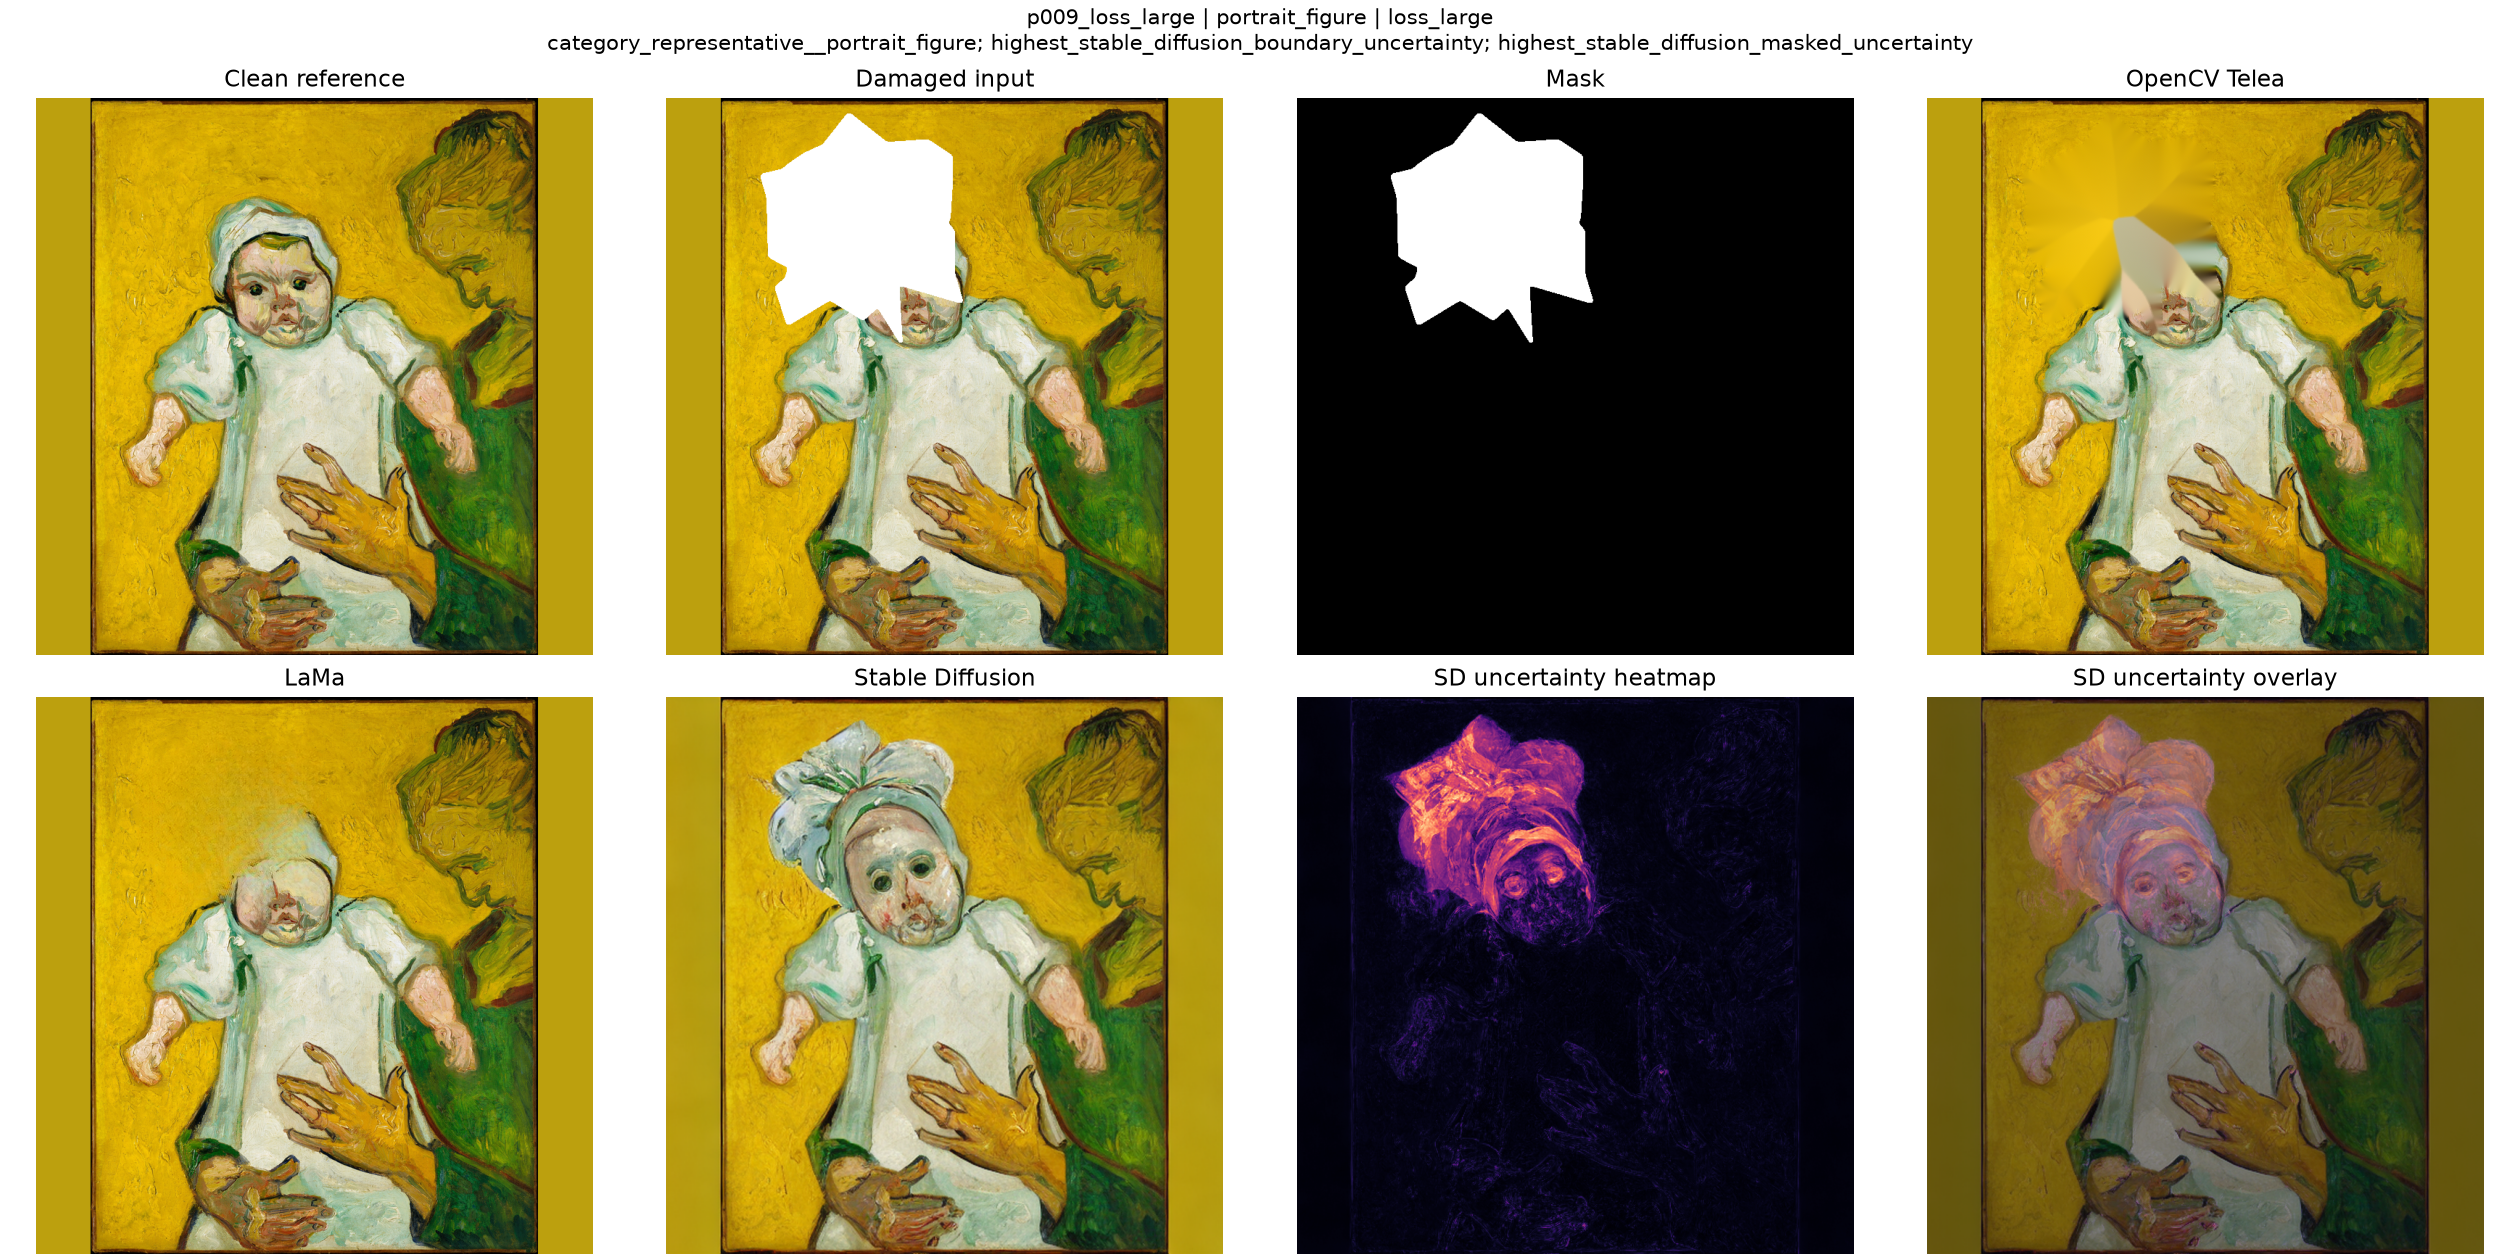

In [13]:
smoke_case_row = selected_cases_df.iloc[0]

print("Smoke-test selected case:")
display(
    pd.DataFrame(
        [
            {
                "case_id": smoke_case_row["case_id"],
                "category": smoke_case_row["category"],
                "mask_type": smoke_case_row["mask_type"],
                "selection_reasons": smoke_case_row["selection_reasons"],
                "has_uncertainty_heatmap": smoke_case_row.get("has_uncertainty_heatmap", False),
                "has_texture_disagreement": smoke_case_row.get("has_texture_disagreement", False),
            }
        ]
    )
)

smoke_grid_path = save_case_diagnostic_grid(smoke_case_row)

print("Smoke-test grid path:", smoke_grid_path)
print("Resolved:", resolve_project_path(smoke_grid_path))
print("Exists:", path_exists_from_value(smoke_grid_path))

display(Image.open(resolve_project_path(smoke_grid_path)))

In [14]:
case_grid_rows = []

print("Generating selected case diagnostic grids:", len(selected_cases_df))

for index, (_, row) in enumerate(selected_cases_df.iterrows(), start=1):
    case_id = row["case_id"]
    print(f"[{index:02d}/{len(selected_cases_df):02d}] {case_id}")

    try:
        grid_path = save_case_diagnostic_grid(row)

        case_grid_rows.append(
            {
                "case_id": case_id,
                "case_diagnostic_grid_path": grid_path,
                "case_grid_status": "ok",
                "case_grid_error_message": "",
            }
        )

    except Exception as error:
        case_grid_rows.append(
            {
                "case_id": case_id,
                "case_diagnostic_grid_path": "",
                "case_grid_status": "error",
                "case_grid_error_message": str(error),
            }
        )

case_grid_status_df = pd.DataFrame(case_grid_rows)

selected_cases_df = selected_cases_df.merge(
    case_grid_status_df,
    on="case_id",
    how="left",
)

selected_cases_df.to_csv(
    output_paths["case_diagnostic_selected_cases"],
    index=False,
)

print("Grid generation status:")
display(
    selected_cases_df["case_grid_status"]
    .value_counts(dropna=False)
    .rename_axis("case_grid_status")
    .reset_index(name="case_count")
)

if (selected_cases_df["case_grid_status"] != "ok").any():
    display(
        selected_cases_df[
            selected_cases_df["case_grid_status"] != "ok"
        ][
            [
                "case_id",
                "case_grid_status",
                "case_grid_error_message",
            ]
        ]
    )

    raise ValueError("Some selected case diagnostic grids failed.")

print("Updated selected cases file:", output_paths["case_diagnostic_selected_cases"])

display(
    selected_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reasons",
            "case_diagnostic_grid_path",
        ]
    ].head(20)
)

Generating selected case diagnostic grids: 30
[01/30] p009_loss_large
[02/30] p011_loss_large
[03/30] p001_loss_large
[04/30] p011_mixed_damage
[05/30] p031_loss_large
[06/30] p041_loss_large
[07/30] p041_loss_small
[08/30] p041_mixed_damage
[09/30] p043_loss_large
[10/30] p009_mixed_damage
[11/30] p018_scratch_thin
[12/30] p026_loss_large
[13/30] p031_mixed_damage
[14/30] p031_scratch_thin
[15/30] p037_loss_large
[16/30] p037_loss_small
[17/30] p037_scratch_thin
[18/30] p041_scratch_thin
[19/30] p001_loss_small
[20/30] p001_mixed_damage
[21/30] p001_scratch_thin
[22/30] p002_loss_large
[23/30] p002_loss_small
[24/30] p002_mixed_damage
[25/30] p002_scratch_thin
[26/30] p019_loss_large
[27/30] p019_loss_small
[28/30] p024_scratch_thin
[29/30] p030_scratch_thin
[30/30] p032_loss_small
Grid generation status:


,case_grid_status,case_count
0,ok,30


Updated selected cases file: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\case_diagnostic_selected_cases_50.csv


,case_id,category,mask_type,selection_reasons,case_diagnostic_grid_path
0,p009_loss_large,portrait_figure,loss_large,category_representative__portrait_figure; high...,outputs/figures/case_diagnostics/selected_case...
1,p011_loss_large,landscape_natural,loss_large,category_representative__landscape_natural; hi...,outputs/figures/case_diagnostics/selected_case...
2,p001_loss_large,portrait_figure,loss_large,lama_strong_refined_metric_wins; stable_diffus...,outputs/figures/case_diagnostics/selected_case...
3,p011_mixed_damage,landscape_natural,mixed_damage,highest_stable_diffusion_masked_uncertainty; m...,outputs/figures/case_diagnostics/selected_case...
4,p031_loss_large,abstraction_surrealism,loss_large,category_representative__abstraction_surrealis...,outputs/figures/case_diagnostics/selected_case...
5,p041_loss_large,high_texture_brushwork,loss_large,high_texture_brushwork_representative; highest...,outputs/figures/case_diagnostics/selected_case...
6,p041_loss_small,high_texture_brushwork,loss_small,high_texture_brushwork_representative; highest...,outputs/figures/case_diagnostics/selected_case...
7,p041_mixed_damage,high_texture_brushwork,mixed_damage,high_texture_brushwork_representative; highest...,outputs/figures/case_diagnostics/selected_case...
8,p043_loss_large,high_texture_brushwork,loss_large,category_representative__high_texture_brushwor...,outputs/figures/case_diagnostics/selected_case...
9,p009_mixed_damage,portrait_figure,mixed_damage,highest_stable_diffusion_boundary_uncertainty,outputs/figures/case_diagnostics/selected_case...


In [15]:
def dataframe_row_to_metric_table_html(
    row: pd.Series,
    *,
    columns: list[str],
    title: str,
) -> str:
    """
    Render selected columns from a row as a two-column HTML table.
    """
    rows = []

    for column in columns:
        if column not in row.index:
            continue

        value = row[column]

        try:
            if pd.isna(value):
                continue
        except TypeError:
            pass

        if isinstance(value, float):
            value_text = format_float(value)
        else:
            value_text = html_escape(value)

        rows.append(
            f"""
            <tr>
                <th>{html_escape(column)}</th>
                <td>{value_text}</td>
            </tr>
            """
        )

    if not rows:
        return ""

    return f"""
    <h2>{html_escape(title)}</h2>
    <table class="metric-table">
        {''.join(rows)}
    </table>
    """


def build_case_page_html(
    row: pd.Series,
    *,
    html_file_path: Path,
) -> str:
    case_id = html_escape(row["case_id"])
    category = html_escape(row.get("category", ""))
    mask_type = html_escape(row.get("mask_type", ""))
    selection_reasons = html_escape(row.get("selection_reasons", ""))

    visual_grid_html = image_tag_for_project_path(
        row.get("case_diagnostic_grid_path", None),
        html_file_path=html_file_path,
        width=1100,
    )

    refined_columns = [
        "overall_metric_vote",
        "refined_overall_metric_vote",
        "refined_opencv_metric_wins",
        "refined_lama_metric_wins",
        "refined_stable_diffusion_metric_wins",
        "opencv_telea_metric_wins",
        "lama_metric_wins",
        "stable_diffusion_inpainting_metric_wins",
        "mixed_metric_outcome",
    ]

    texture_columns = [
        "has_texture_disagreement",
        "texture_texture_winner",
        "texture_texture_winner_model",
        "texture_combined_texture_distance_winner",
        "texture_combined_texture_distance_mean_winner",
        "texture_combined_texture_distance_norm_winner",
        "texture_glcm_texture_distance_mean_winner",
        "texture_gabor_texture_distance_mean_winner",
        "texture_brushstroke_proxy_distance_mean_winner",
        "texture_texture_winner_is_refined_winner",
        "texture_texture_refined_agreement",
    ]

    uncertainty_columns = [
        "has_uncertainty_heatmap",
        "uncertainty_masked_mean_uncertainty",
        "uncertainty_masked_p95_uncertainty",
        "uncertainty_bbox_mean_uncertainty",
        "uncertainty_bbox_p95_uncertainty",
        "uncertainty_boundary_mean_uncertainty",
        "uncertainty_boundary_p95_uncertainty",
        "uncertainty_outside_mask_mean_uncertainty",
        "uncertainty_outside_mask_p95_uncertainty",
        "uncertainty_masked_vs_global_mean_uncertainty_ratio",
        "uncertainty_boundary_vs_global_mean_uncertainty_ratio",
        "uncertainty_selected_selection_reasons",
    ]

    path_columns = [
        "clean_image_path_relative",
        "damaged_image_path_relative",
        "mask_image_path_relative",
        "opencv_image_path_relative",
        "lama_image_path_relative",
        "stable_diffusion_image_path_relative",
        "uncertainty_heatmap_png_path",
        "uncertainty_overlay_png_path",
        "case_diagnostic_grid_path",
    ]

    refined_table = dataframe_row_to_metric_table_html(
        row,
        columns=refined_columns,
        title="Refined metric summary",
    )

    texture_table = dataframe_row_to_metric_table_html(
        row,
        columns=texture_columns,
        title="Texture and brushstroke-proxy diagnostics",
    )

    uncertainty_table = dataframe_row_to_metric_table_html(
        row,
        columns=uncertainty_columns,
        title="Stable Diffusion uncertainty diagnostics",
    )

    path_table = dataframe_row_to_metric_table_html(
        row,
        columns=path_columns,
        title="Source paths",
    )

    uncertainty_extra_html = ""

    if bool(row.get("has_uncertainty_heatmap", False)):
        heatmap_html = image_tag_for_project_path(
            row.get("uncertainty_heatmap_png_path", None),
            html_file_path=html_file_path,
            width=500,
        )

        overlay_html = image_tag_for_project_path(
            row.get("uncertainty_overlay_png_path", None),
            html_file_path=html_file_path,
            width=500,
        )

        uncertainty_extra_html = f"""
        <h2>Uncertainty heatmap assets</h2>
        <div class="side-by-side">
            <div>
                <h3>Heatmap</h3>
                {heatmap_html}
            </div>
            <div>
                <h3>Overlay</h3>
                {overlay_html}
            </div>
        </div>
        """

    html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Case Diagnostic Report — {case_id}</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 32px;
            line-height: 1.5;
            color: #222;
        }}
        h1, h2, h3 {{
            color: #111;
        }}
        .note {{
            background: #f5f5f5;
            border-left: 4px solid #555;
            padding: 12px;
            margin: 16px 0;
        }}
        .metric-table {{
            border-collapse: collapse;
            margin: 12px 0 24px 0;
            font-size: 13px;
            width: 100%;
        }}
        .metric-table th, .metric-table td {{
            border: 1px solid #ccc;
            padding: 6px 8px;
            text-align: left;
            vertical-align: top;
        }}
        .metric-table th {{
            background: #eee;
            width: 280px;
        }}
        img {{
            max-width: 100%;
            height: auto;
            border: 1px solid #ddd;
        }}
        .side-by-side {{
            display: flex;
            gap: 24px;
            align-items: flex-start;
            flex-wrap: wrap;
        }}
        a {{
            color: #0645ad;
        }}
    </style>
</head>
<body>
    <p><a href="../case_report_index.html">Back to case report index</a></p>

    <h1>Case Diagnostic Report — {case_id}</h1>

    <div class="note">
        <strong>Category:</strong> {category}<br>
        <strong>Mask type:</strong> {mask_type}<br>
        <strong>Selection reasons:</strong> {selection_reasons}
    </div>

    <h2>Visual diagnostic grid</h2>
    {visual_grid_html}

    {refined_table}

    {texture_table}

    {uncertainty_table}

    {uncertainty_extra_html}

    {path_table}

    <h2>Interpretation note</h2>
    <p>
        This case report combines visual outputs and diagnostic summaries already generated in earlier notebooks.
        It is intended for inspection and thesis reporting, not as a new metric computation.
    </p>
</body>
</html>
"""

    return html


print("Case page HTML helpers ready.")

Case page HTML helpers ready.


In [16]:
case_page_rows = []

print("Generating selected case HTML pages:", len(selected_cases_df))

for index, (_, row) in enumerate(selected_cases_df.iterrows(), start=1):
    case_id = str(row["case_id"])
    safe_case_id = case_id.replace("/", "_").replace("\\", "_").replace(":", "_")

    html_path = case_report_pages_dir / f"{safe_case_id}_case_diagnostic.html"

    print(f"[{index:02d}/{len(selected_cases_df):02d}] {case_id}")

    try:
        html = build_case_page_html(
            row,
            html_file_path=html_path,
        )

        html_path.write_text(html, encoding="utf-8")

        case_page_rows.append(
            {
                "case_id": case_id,
                "case_report_html_path": to_project_relative_path(html_path),
                "case_report_status": "ok",
                "case_report_error_message": "",
            }
        )

    except Exception as error:
        case_page_rows.append(
            {
                "case_id": case_id,
                "case_report_html_path": "",
                "case_report_status": "error",
                "case_report_error_message": str(error),
            }
        )

case_page_status_df = pd.DataFrame(case_page_rows)

selected_cases_df = selected_cases_df.merge(
    case_page_status_df,
    on="case_id",
    how="left",
)

selected_cases_df.to_csv(
    output_paths["case_diagnostic_selected_cases"],
    index=False,
)

print("Case page generation status:")
display(
    selected_cases_df["case_report_status"]
    .value_counts(dropna=False)
    .rename_axis("case_report_status")
    .reset_index(name="case_count")
)

if (selected_cases_df["case_report_status"] != "ok").any():
    display(
        selected_cases_df[
            selected_cases_df["case_report_status"] != "ok"
        ][
            [
                "case_id",
                "case_report_status",
                "case_report_error_message",
            ]
        ]
    )

    raise ValueError("Some selected case HTML pages failed.")

print("Updated selected cases file:", output_paths["case_diagnostic_selected_cases"])

display(
    selected_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "case_report_html_path",
            "case_diagnostic_grid_path",
        ]
    ].head(20)
)

Generating selected case HTML pages: 30
[01/30] p009_loss_large
[02/30] p011_loss_large
[03/30] p001_loss_large
[04/30] p011_mixed_damage
[05/30] p031_loss_large
[06/30] p041_loss_large
[07/30] p041_loss_small
[08/30] p041_mixed_damage
[09/30] p043_loss_large
[10/30] p009_mixed_damage
[11/30] p018_scratch_thin
[12/30] p026_loss_large
[13/30] p031_mixed_damage
[14/30] p031_scratch_thin
[15/30] p037_loss_large
[16/30] p037_loss_small
[17/30] p037_scratch_thin
[18/30] p041_scratch_thin
[19/30] p001_loss_small
[20/30] p001_mixed_damage
[21/30] p001_scratch_thin
[22/30] p002_loss_large
[23/30] p002_loss_small
[24/30] p002_mixed_damage
[25/30] p002_scratch_thin
[26/30] p019_loss_large
[27/30] p019_loss_small
[28/30] p024_scratch_thin
[29/30] p030_scratch_thin
[30/30] p032_loss_small
Case page generation status:


,case_report_status,case_count
0,ok,30


Updated selected cases file: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\case_diagnostic_selected_cases_50.csv


,case_id,category,mask_type,case_report_html_path,case_diagnostic_grid_path
0,p009_loss_large,portrait_figure,loss_large,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
1,p011_loss_large,landscape_natural,loss_large,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
2,p001_loss_large,portrait_figure,loss_large,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
3,p011_mixed_damage,landscape_natural,mixed_damage,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
4,p031_loss_large,abstraction_surrealism,loss_large,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
5,p041_loss_large,high_texture_brushwork,loss_large,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
6,p041_loss_small,high_texture_brushwork,loss_small,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
7,p041_mixed_damage,high_texture_brushwork,mixed_damage,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
8,p043_loss_large,high_texture_brushwork,loss_large,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...
9,p009_mixed_damage,portrait_figure,mixed_damage,outputs/reports/case_diagnostics/selected_case...,outputs/figures/case_diagnostics/selected_case...


In [17]:
manifest_columns = [
    column
    for column in [
        "case_id",
        "painting_id",
        "mask_id",
        "category",
        "mask_type",
        "selection_reasons",
        "selection_count",
        "has_uncertainty_heatmap",
        "has_texture_disagreement",
        "case_diagnostic_grid_path",
        "case_report_html_path",
        "clean_image_path_relative",
        "damaged_image_path_relative",
        "mask_image_path_relative",
        "opencv_image_path_relative",
        "lama_image_path_relative",
        "stable_diffusion_image_path_relative",
        "uncertainty_heatmap_png_path",
        "uncertainty_overlay_png_path",
        "uncertainty_masked_mean_uncertainty",
        "uncertainty_boundary_mean_uncertainty",
        stable_diffusion_win_column,
        opencv_win_column,
        lama_win_column,
    ]
    if column is not None and column in selected_cases_df.columns
]

case_report_manifest_df = selected_cases_df[manifest_columns].copy()

case_report_manifest_df.to_csv(
    output_paths["case_diagnostic_manifest"],
    index=False,
)

print("Saved case diagnostic manifest:", output_paths["case_diagnostic_manifest"])
print("Manifest shape:", case_report_manifest_df.shape)

display(case_report_manifest_df.head(20))

Saved case diagnostic manifest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\case_diagnostic_report_manifest_50.csv
Manifest shape: (30, 24)


,case_id,painting_id,mask_id,category,mask_type,selection_reasons,selection_count,has_uncertainty_heatmap,has_texture_disagreement,case_diagnostic_grid_path,case_report_html_path,clean_image_path_relative,damaged_image_path_relative,mask_image_path_relative,opencv_image_path_relative,lama_image_path_relative,stable_diffusion_image_path_relative,uncertainty_heatmap_png_path,uncertainty_overlay_png_path,uncertainty_masked_mean_uncertainty,uncertainty_boundary_mean_uncertainty,stable_diffusion_inpainting_metric_wins,opencv_telea_metric_wins,lama_metric_wins
0,p009_loss_large,p009,p009_loss_large,portrait_figure,loss_large,category_representative__portrait_figure; high...,3,True,True,outputs/figures/case_diagnostics/selected_case...,outputs/reports/case_diagnostics/selected_case...,data/processed/clean/p009_clean.png,data/processed/masked/p009_loss_large_damaged.png,data/processed/masks/p009_loss_large_mask.png,data/processed/restored/opencv_telea/p009_loss...,data/processed/restored/lama/p009_loss_large_r...,data/processed/restored/stable_diffusion_inpai...,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,37.621746,8.283583,2,1,3
1,p011_loss_large,p011,p011_loss_large,landscape_natural,loss_large,category_representative__landscape_natural; hi...,3,True,True,outputs/figures/case_diagnostics/selected_case...,outputs/reports/case_diagnostics/selected_case...,data/processed/clean/p011_clean.png,data/processed/masked/p011_loss_large_damaged.png,data/processed/masks/p011_loss_large_mask.png,data/processed/restored/opencv_telea/p011_loss...,data/processed/restored/lama/p011_loss_large_r...,data/processed/restored/stable_diffusion_inpai...,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,38.245800,4.813465,0,1,5
2,p001_loss_large,p001,p001_loss_large,portrait_figure,loss_large,lama_strong_refined_metric_wins; stable_diffus...,3,False,True,outputs/figures/case_diagnostics/selected_case...,outputs/reports/case_diagnostics/selected_case...,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_large_damaged.png,data/processed/masks/p001_loss_large_mask.png,data/processed/restored/opencv_telea/p001_loss...,data/processed/restored/lama/p001_loss_large_r...,data/processed/restored/stable_diffusion_inpai...,NaN,NaN,NaN,NaN,0,0,6
3,p011_mixed_damage,p011,p011_mixed_damage,landscape_natural,mixed_damage,highest_stable_diffusion_masked_uncertainty; m...,2,True,True,outputs/figures/case_diagnostics/selected_case...,outputs/reports/case_diagnostics/selected_case...,data/processed/clean/p011_clean.png,data/processed/masked/p011_mixed_damage_damage...,data/processed/masks/p011_mixed_damage_mask.png,data/processed/restored/opencv_telea/p011_mixe...,data/processed/restored/lama/p011_mixed_damage...,data/processed/restored/stable_diffusion_inpai...,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,24.741758,4.385314,0,1,5
4,p031_loss_large,p031,p031_loss_large,abstraction_surrealism,loss_large,category_representative__abstraction_surrealis...,2,True,True,outputs/figures/case_diagnostics/selected_case...,outputs/reports/case_diagnostics/selected_case...,data/processed/clean/p031_clean.png,data/processed/masked/p031_loss_large_damaged.png,data/processed/masks/p031_loss_large_mask.png,data/processed/restored/opencv_telea/p031_loss...,data/processed/restored/lama/p031_loss_large_r...,data/processed/restored/stable_diffusion_inpai...,outputs/figures/uncertainty_heatmaps/heatmap_i...,outputs/figures/uncertainty_heatmaps/overlay_i...,27.727493,7.723886,0,1,5
5,p041_loss_large,p041,p041_loss_large,high_texture_brushwork,loss_large,high_texture_brushwork_representative; highest...,2,True,True,outputs/figures/case_diagnostics/selected_case...,outputs/reports/case_diagnostics/selected_case...,data/processed/clean/p041_clean.png,data/processed/masked/p041_loss_large_damaged.png,data/processed/masks/p041_

In [18]:
def dataframe_to_index_table_html(
    df: pd.DataFrame,
    *,
    html_file_path: Path,
) -> str:
    rows = []

    for _, row in df.iterrows():
        report_path = row.get("case_report_html_path", "")
        grid_path = row.get("case_diagnostic_grid_path", "")

        report_src = path_to_html_src(
            report_path,
            html_file_path=html_file_path,
        ) if report_path else ""

        grid_src = path_to_html_src(
            grid_path,
            html_file_path=html_file_path,
        ) if grid_path else ""

        report_link = (
            f'<a href="{html_escape(report_src)}">Open report</a>'
            if report_src
            else ""
        )

        grid_link = (
            f'<a href="{html_escape(grid_src)}">Open grid</a>'
            if grid_src
            else ""
        )

        rows.append(
            f"""
            <tr>
                <td>{html_escape(row.get("case_id", ""))}</td>
                <td>{html_escape(row.get("category", ""))}</td>
                <td>{html_escape(row.get("mask_type", ""))}</td>
                <td>{html_escape(row.get("selection_reasons", ""))}</td>
                <td>{html_escape(row.get("has_uncertainty_heatmap", ""))}</td>
                <td>{html_escape(row.get("has_texture_disagreement", ""))}</td>
                <td>{format_float(row.get("uncertainty_masked_mean_uncertainty", np.nan))}</td>
                <td>{format_float(row.get("uncertainty_boundary_mean_uncertainty", np.nan))}</td>
                <td>{report_link}</td>
                <td>{grid_link}</td>
            </tr>
            """
        )

    return "\n".join(rows)


index_path = output_paths["case_report_index"]

selection_summary_df = (
    selected_reasons_df
    .groupby("selection_reason", as_index=False)
    .agg(raw_selection_count=("case_id", "count"))
    .sort_values("raw_selection_count", ascending=False)
)

category_summary_df = (
    selected_cases_df
    .groupby("category", as_index=False)
    .agg(selected_cases=("case_id", "count"))
    .sort_values("selected_cases", ascending=False)
)

mask_type_summary_df = (
    selected_cases_df
    .groupby("mask_type", as_index=False)
    .agg(selected_cases=("case_id", "count"))
    .sort_values("selected_cases", ascending=False)
)

selection_summary_html = selection_summary_df.to_html(
    index=False,
    escape=True,
    border=0,
    classes="data-table",
)

category_summary_html = category_summary_df.to_html(
    index=False,
    escape=True,
    border=0,
    classes="data-table",
)

mask_type_summary_html = mask_type_summary_df.to_html(
    index=False,
    escape=True,
    border=0,
    classes="data-table",
)

case_table_rows_html = dataframe_to_index_table_html(
    selected_cases_df,
    html_file_path=index_path,
)

index_html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Selected Case Diagnostic Report Index</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 32px;
            line-height: 1.5;
            color: #222;
        }}
        h1, h2, h3 {{
            color: #111;
        }}
        .note {{
            background: #f5f5f5;
            border-left: 4px solid #555;
            padding: 12px;
            margin: 16px 0;
        }}
        .data-table, .case-table {{
            border-collapse: collapse;
            margin: 12px 0 24px 0;
            font-size: 13px;
            width: 100%;
        }}
        .data-table th, .data-table td,
        .case-table th, .case-table td {{
            border: 1px solid #ccc;
            padding: 6px 8px;
            text-align: left;
            vertical-align: top;
        }}
        .data-table th, .case-table th {{
            background: #eee;
        }}
        a {{
            color: #0645ad;
        }}
    </style>
</head>
<body>
    <h1>Selected Case Diagnostic Report Index</h1>

    <div class="note">
        This index links selected per-case diagnostic reports generated by Notebook 33.
        Reports combine model outputs, refined metric summaries, texture/brushstroke-proxy diagnostics,
        and Stable Diffusion uncertainty heatmap information when available.
    </div>

    <h2>Summary</h2>
    <ul>
        <li>Total controlled cases available: {case_diagnostic_df["case_id"].nunique()}</li>
        <li>Selected diagnostic cases: {selected_cases_df["case_id"].nunique()}</li>
        <li>Cases with Stable Diffusion uncertainty heatmaps: {int(selected_cases_df["has_uncertainty_heatmap"].sum())}</li>
        <li>Cases with texture/refined disagreement flag: {int(selected_cases_df["has_texture_disagreement"].sum())}</li>
    </ul>

    <h2>Selection reason summary</h2>
    {selection_summary_html}

    <h2>Selected cases by category</h2>
    {category_summary_html}

    <h2>Selected cases by mask type</h2>
    {mask_type_summary_html}

    <h2>Selected case reports</h2>
    <table class="case-table">
        <thead>
            <tr>
                <th>Case ID</th>
                <th>Category</th>
                <th>Mask type</th>
                <th>Selection reasons</th>
                <th>Has uncertainty heatmap</th>
                <th>Has texture disagreement</th>
                <th>Masked uncertainty</th>
                <th>Boundary uncertainty</th>
                <th>Report</th>
                <th>Grid</th>
            </tr>
        </thead>
        <tbody>
            {case_table_rows_html}
        </tbody>
    </table>

    <h2>Interpretation note</h2>
    <p>
        These reports are inspection artifacts. They do not replace aggregate metric summaries.
        Their purpose is to make individual case behavior visible, especially where refined metrics,
        texture diagnostics, and Stable Diffusion uncertainty diverge.
    </p>
</body>
</html>
"""

index_path.write_text(index_html, encoding="utf-8")

print("Saved case report index:", index_path)
print("Index size MB:", round(index_path.stat().st_size / (1024 * 1024), 3))

Saved case report index: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\case_diagnostics\case_report_index.html
Index size MB: 0.023


In [20]:
required_output_files = [
    output_paths["case_diagnostic_manifest"],
    output_paths["case_diagnostic_selected_cases"],
    output_paths["case_report_index"],
]

missing_required_output_files = [
    path
    for path in required_output_files
    if not path.exists()
]

if missing_required_output_files:
    for path in missing_required_output_files:
        print("Missing:", path)

    raise FileNotFoundError("Some required Notebook 33 output files are missing.")

if case_diagnostic_df["case_id"].nunique() != 200:
    raise ValueError(
        f"Expected 200 total controlled cases, got {case_diagnostic_df['case_id'].nunique()}."
    )

if selected_cases_df.empty:
    raise ValueError("Selected cases dataframe is empty.")

if selected_cases_df["case_id"].duplicated().any():
    duplicated_selected_cases = selected_cases_df[
        selected_cases_df["case_id"].duplicated(keep=False)
    ]

    display(duplicated_selected_cases[["case_id", "selection_reasons"]])

    raise ValueError("Selected cases dataframe contains duplicate case_id rows.")

if (selected_cases_df["case_grid_status"] != "ok").any():
    raise ValueError("Not all selected case grids were generated successfully.")

if (selected_cases_df["case_report_status"] != "ok").any():
    raise ValueError("Not all selected case report pages were generated successfully.")

missing_grid_files = []

for path_value in selected_cases_df["case_diagnostic_grid_path"].dropna():
    resolved_path = resolve_project_path(path_value)

    if resolved_path is None or not resolved_path.exists():
        missing_grid_files.append(path_value)

if missing_grid_files:
    print("Missing grid files:")
    for path_value in missing_grid_files[:20]:
        print(path_value)

    raise FileNotFoundError("Some selected case diagnostic grid files are missing.")

missing_report_files = []

for path_value in selected_cases_df["case_report_html_path"].dropna():
    resolved_path = resolve_project_path(path_value)

    if resolved_path is None or not resolved_path.exists():
        missing_report_files.append(path_value)

if missing_report_files:
    print("Missing report files:")
    for path_value in missing_report_files[:20]:
        print(path_value)

    raise FileNotFoundError("Some selected case HTML report files are missing.")

index_html_text = output_paths["case_report_index"].read_text(encoding="utf-8")

if "Selected Case Diagnostic Report Index" not in index_html_text:
    raise ValueError("Case report index does not contain expected title.")

if index_html_text.count("Open report") != len(selected_cases_df):
    raise ValueError(
        "Case report index does not contain one report link per selected case."
    )

print("Notebook 33 final validation passed.")
print("Total controlled cases:", case_diagnostic_df["case_id"].nunique())
print("Selected cases:", selected_cases_df["case_id"].nunique())
print("Cases with uncertainty heatmaps:", int(selected_cases_df["has_uncertainty_heatmap"].sum()))
print("Cases with texture disagreement:", int(selected_cases_df["has_texture_disagreement"].sum()))
print("Case report index:", output_paths["case_report_index"])
print("Selected cases CSV:", output_paths["case_diagnostic_selected_cases"])
print("Manifest CSV:", output_paths["case_diagnostic_manifest"])

print("\nSelected cases by category:")
display(
    selected_cases_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="selected_cases")
)

print("\nSelected cases by mask type:")
display(
    selected_cases_df["mask_type"]
    .value_counts()
    .rename_axis("mask_type")
    .reset_index(name="selected_cases")
)

Notebook 33 final validation passed.
Total controlled cases: 200
Selected cases: 30
Cases with uncertainty heatmaps: 17
Cases with texture disagreement: 30
Case report index: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\case_diagnostics\case_report_index.html
Selected cases CSV: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\case_diagnostic_selected_cases_50.csv
Manifest CSV: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\case_diagnostic_report_manifest_50.csv

Selected cases by category:


,category,selected_cases
0,portrait_figure,10
1,abstraction_surrealism,7
2,landscape_natural,5
3,high_texture_brushwork,5
4,architecture_structured,3



Selected cases by mask type:


,mask_type,selected_cases
0,loss_large,10
1,scratch_thin,8
2,mixed_damage,6
3,loss_small,6


## Notebook 33 summary

This notebook generated selected per-case diagnostic reports for the controlled restoration evaluation.

The notebook combines existing artifacts from earlier stages of the pipeline:

- clean reference image,
- damaged input,
- binary mask,
- OpenCV Telea restoration,
- LaMa restoration,
- Stable Diffusion restoration,
- refined reference-based metric summaries,
- texture and brushstroke-proxy diagnostics where available,
- Stable Diffusion uncertainty heatmap diagnostics where available.

No restoration models were rerun, and no core metrics were recomputed.

The selected cases were chosen using deterministic criteria, including:

- high Stable Diffusion masked-region uncertainty,
- high Stable Diffusion boundary-ring uncertainty,
- texture/refined disagreement cases,
- high-texture brushwork representatives,
- Stable Diffusion low refined metric-win cases,
- OpenCV and LaMa strong cases where metric-win columns were available,
- category representatives,
- mask-type representatives.

Main outputs:

- `outputs/metrics/case_diagnostic_selected_cases_50.csv`
- `outputs/metrics/case_diagnostic_report_manifest_50.csv`
- `outputs/reports/case_diagnostics/case_report_index.html`
- selected individual HTML case reports,
- selected diagnostic grid figures.

The case reports are inspection artifacts. They support supervisor review and thesis writing by showing where aggregate metric results, texture diagnostics, and Stable Diffusion uncertainty behavior can diverge at the individual-case level.